# Inspect clinician annotations

Operator-only notebook: pull every clinician's annotation payload from Supabase, summarize progress, and dump per-clinician JSON files to disk for archival / spot-checking.

**Prerequisites**
1. `notebooks/.env` already populated with `SUPABASE_URL` + `SUPABASE_SERVICE_ROLE_KEY`.
2. `pip install -r notebooks/requirements.txt` (adds `matplotlib` for the stacked bar chart).

Exports land in `notebooks/exports/<timestamp>/<clinician_email>/<row_id>__<status>.json` — that directory is gitignored.

In [8]:
from __future__ import annotations

import json
import os
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from supabase import create_client

load_dotenv(Path("notebooks/.env"))
load_dotenv(Path(".env"))

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_SERVICE_ROLE_KEY = os.environ["SUPABASE_SERVICE_ROLE_KEY"]

REPO_ROOT = Path.cwd() if (Path.cwd() / "supabase" / "schema.sql").exists() else Path.cwd().parent
EXPORTS_ROOT = REPO_ROOT / "notebooks" / "exports"
RUN_STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR = EXPORTS_ROOT / RUN_STAMP

sb = create_client(SUPABASE_URL, SUPABASE_SERVICE_ROLE_KEY)
print("Supabase client ready")
print("Run output dir:", OUTPUT_DIR)

Supabase client ready
Run output dir: c:\Users\Lough\Desktop\Research\[Yale] Postdoctoral Research\Readmission\notebooks\exports\20260526T154932Z


## Fetch master tables

One read per table. Everything below is in-memory joins.

In [9]:
def fetch_all(table: str, columns: str) -> pd.DataFrame:
    rows: list[dict] = []
    page_size = 1000
    offset = 0
    while True:
        res = (
            sb.table(table)
            .select(columns)
            .range(offset, offset + page_size - 1)
            .execute()
        )
        batch = res.data or []
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return pd.DataFrame(rows)


profiles_df = fetch_all("profiles", "id,display_name,role")
assignments_df = fetch_all(
    "assignments",
    "user_id,row_id,status,assigned_at,submitted_at",
)
annotations_df = fetch_all(
    "annotations",
    "user_id,row_id,payload,status,updated_at",
)
cases_df = fetch_all(
    "cases",
    "row_id,subject_id,index_hadm_id,readmit_hadm_id,days_to_readmit",
)

# Email isn't on public.profiles — pull it from the admin API for human-readable joins.
admin_users = sb.auth.admin.list_users()
email_by_uid = {
    getattr(u, "id", None): (getattr(u, "email", "") or "").lower()
    for u in (admin_users or [])
}
profiles_df["email"] = profiles_df["id"].map(email_by_uid).fillna("")

print(f"profiles: {len(profiles_df)}")
print(f"assignments: {len(assignments_df)}")
print(f"annotations: {len(annotations_df)}")
print(f"cases: {len(cases_df)}")

profiles: 2
assignments: 60
annotations: 8
cases: 60


## Per-clinician completion summary

Counts come from `public.assignments.status` so the totals match what the clinician sees in the Notes Left tab.

,status,not_started,in_progress,draft,submitted,total,pct_done
email,display_name,,,,,,
krumholz@yale.edu,Clinician A,23,0,1,6,30,20.0
karthik@yale.edu,Clinician B,30,0,0,0,30,0.0


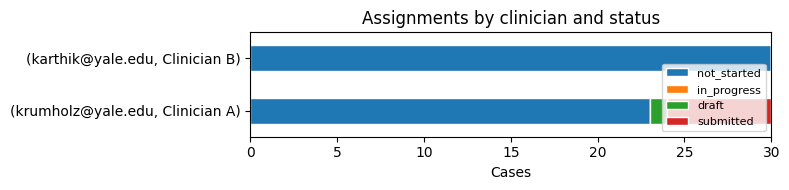

In [27]:
STATUS_ORDER = ["not_started", "in_progress", "draft", "submitted"]

joined = assignments_df.merge(
    profiles_df[["id", "display_name", "email"]],
    left_on="user_id",
    right_on="id",
    how="left",
).drop(columns=["id"])

summary = (
    joined.groupby(["email", "display_name", "status"])
    .size()
    .unstack(fill_value=0)
)
for col in STATUS_ORDER:
    if col not in summary.columns:
        summary[col] = 0
summary = summary[STATUS_ORDER]
summary["total"] = summary.sum(axis=1)
summary["pct_done"] = (summary["submitted"] / summary["total"] * 100).round(1)
summary = summary.sort_values("submitted", ascending=False)

display(summary)

try:
    import matplotlib.pyplot as plt

    plot_cols = [c for c in STATUS_ORDER if c in summary.columns]
    ax = summary[plot_cols].plot(
        kind="barh",
        stacked=True,
        figsize=(8, max(2, 0.6 * len(summary))),
        edgecolor="white",
    )
    ax.set_xlabel("Cases")
    ax.set_ylabel("")
    ax.set_title("Assignments by clinician and status")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("matplotlib not installed — skipping bar chart")

## Per-case detail

One row per `(clinician, case)`. `factors` and `spans` come from the JSONB payload — they're meaningful only for cases the clinician has started touching.

In [25]:
def _payload_dict(value) -> dict:
    if isinstance(value, dict):
        return value
    if isinstance(value, str) and value:
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return {}
    return {}


detail = assignments_df.merge(
    profiles_df[["id", "email", "display_name"]],
    left_on="user_id",
    right_on="id",
    how="left",
).drop(columns=["id"])

detail = detail.merge(
    cases_df,
    on="row_id",
    how="left",
)

ann_lookup = {
    (row["user_id"], row["row_id"]): row
    for _, row in annotations_df.iterrows()
}


def annotation_stats(user_id: str, row_id: str) -> dict:
    row = ann_lookup.get((user_id, row_id))
    if row is None:
        return {
            "annotation_status": None,
            "annotation_updated_at": None,
            "factors": 0,
            "spans": 0,
            "groups": 0,
        }
    payload = _payload_dict(row.get("payload"))
    return {
        "annotation_status": row.get("status"),
        "annotation_updated_at": row.get("updated_at"),
        "factors": len(payload.get("factors", []) or []),
        "spans": len(payload.get("evidenceSpans", []) or []),
        "groups": len(payload.get("evidenceGroups", []) or []),
    }


stats = detail.apply(
    lambda r: annotation_stats(r["user_id"], r["row_id"]),
    axis=1,
    result_type="expand",
)
detail = pd.concat([detail, stats], axis=1)

detail_view = detail[
    [
        "email",
        "display_name",
        "row_id",
        "subject_id",
        "index_hadm_id",
        "readmit_hadm_id",
        "days_to_readmit",
        "status",
        "annotation_status",
        "annotation_updated_at",
        "submitted_at",
        "factors",
        "spans",
        "groups",
    ]
].sort_values(["email", "status", "row_id"])

display(detail_view)

,email,display_name,row_id,subject_id,index_hadm_id,readmit_hadm_id,days_to_readmit,status,annotation_status,annotation_updated_at,submitted_at,factors,spans,groups
48,karthik@yale.edu,Clinician B,137,7107,148024,104098,4,not_started,NaN,NaN,NaN,0.0,0.0,0.0
49,karthik@yale.edu,Clinician B,139,7192,128007,188914,13,not_started,NaN,NaN,NaN,0.0,0.0,0.0
32,karthik@yale.edu,Clinician B,215,10689,116873,109618,6,not_started,NaN,NaN,NaN,0.0,0.0,0.0
24,karthik@yale.edu,Clinician B,218,10774,173586,197363,2,not_started,NaN,NaN,NaN,0.0,0.0,0.0
29,karthik@yale.edu,Clinician B,23,1354,135614,144830,18,not_started,NaN,NaN,NaN,0.0,0.0,0.0
37,karthik@yale.edu,Clinician B,235,11318,111001,151558,15,not_started,NaN,NaN,NaN,0.0,0.0,0.0
46,karthik@yale.edu,Clinician B,266,13542,115692,159934,7,not_started,NaN,NaN,NaN,0.0,0.0,0.0
38,karthik@yale.edu,Clinician B,312,16072,184897,151600,14,not_started,NaN,NaN,NaN,0.0,0.0,0.0
30,karthik@yale.edu,Clinician B,338,17145,105119,194283,21,not_started,NaN,NaN,NaN,0.0,0.0,0.0
26,karthik@yale.edu,Clinician B,346,17539,178324,127310,27,not_started,NaN,NaN,NaN,0.0,0.0,0.0


## Dump per-clinician JSON exports

Writes one file per annotation row at `notebooks/exports/<RUN_STAMP>/<email>/<row_id>__<status>.json`.

In [12]:
def _safe_segment(value: str) -> str:
    cleaned = "".join(c if c.isalnum() or c in "-_.@" else "_" for c in str(value))
    return cleaned or "unknown"


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
case_lookup = {row["row_id"]: row for _, row in cases_df.iterrows()}
written = 0

for _, ann in annotations_df.iterrows():
    user_id = ann["user_id"]
    row_id = ann["row_id"]
    email = email_by_uid.get(user_id) or _safe_segment(user_id)
    case = case_lookup.get(row_id, {})
    payload = _payload_dict(ann.get("payload"))

    record = {
        "exported_at": datetime.now(timezone.utc).isoformat(),
        "clinician": {
            "user_id": user_id,
            "email": email,
        },
        "case": {
            "row_id": row_id,
            "subject_id": case.get("subject_id", ""),
            "index_hadm_id": case.get("index_hadm_id", ""),
            "readmit_hadm_id": case.get("readmit_hadm_id", ""),
        },
        "status": ann.get("status"),
        "updated_at": str(ann.get("updated_at")) if ann.get("updated_at") is not None else None,
        "payload": payload,
    }

    target_dir = OUTPUT_DIR / _safe_segment(email)
    target_dir.mkdir(parents=True, exist_ok=True)
    fname = f"{_safe_segment(row_id)}__{_safe_segment(ann.get('status') or 'unknown')}.json"
    target_path = target_dir / fname
    target_path.write_text(
        json.dumps(record, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )
    written += 1

print(f"Wrote {written} annotation files to {OUTPUT_DIR}")

Wrote 8 annotation files to c:\Users\Lough\Desktop\Research\[Yale] Postdoctoral Research\Readmission\notebooks\exports\20260526T154932Z


## Inspect one annotation

Change `INSPECT_EMAIL` and `INSPECT_ROW_ID` to peek at a specific clinician/case.

In [ ]:
INSPECT_EMAIL = "krumholz@yale.edu"  
INSPECT_ROW_ID = 523  


def _pick_target() -> tuple[str | None, str | None]:
    if INSPECT_EMAIL and INSPECT_ROW_ID:
        return INSPECT_EMAIL, INSPECT_ROW_ID
    candidates = detail_view[detail_view["annotation_status"].notna()]
    if INSPECT_EMAIL:
        candidates = candidates[candidates["email"] == INSPECT_EMAIL]
    if candidates.empty:
        return None, None
    submitted = candidates[candidates["annotation_status"] == "submitted"]
    pick = submitted.iloc[0] if not submitted.empty else candidates.iloc[0]
    return pick["email"], pick["row_id"]


target_email, target_row_id = _pick_target()
if not target_email:
    print("No annotation payloads found to inspect.")
else:
    target_path = (
        OUTPUT_DIR
        / _safe_segment(target_email)
        / f"{_safe_segment(target_row_id)}__"
    )
    matches = list(target_path.parent.glob(f"{_safe_segment(target_row_id)}__*.json"))
    if not matches:
        print(f"No exported file for {target_email} / {target_row_id}")
    else:
        record = json.loads(matches[0].read_text(encoding="utf-8"))
        payload = record.get("payload", {}) or {}
        factors = payload.get("factors", []) or []
        spans_by_factor: dict[str, int] = {}
        for span in payload.get("evidenceSpans", []) or []:
            fid = span.get("factorId")
            if fid:
                spans_by_factor[fid] = spans_by_factor.get(fid, 0) + 1

        rows = []
        for f in factors:
            note = (f.get("note") or "").strip()
            rows.append(
                {
                    "label": f.get("label", ""),
                    "role": f.get("role", ""),
                    "confidence": f.get("confidence"),
                    "modifiability": f.get("modifiability", ""),
                    "spans": spans_by_factor.get(f.get("id"), 0),
                    "note_words": len(note.split()) if note else 0,
                }
            )
        print(f"Inspecting {target_email} / case {target_row_id}")
        print(f"Status: {record.get('status')} · updated_at: {record.get('updated_at')}")
        print(f"Groups: {len(payload.get('evidenceGroups', []) or [])} · "
              f"Factors: {len(factors)} · "
              f"Spans: {len(payload.get('evidenceSpans', []) or [])}")
        display(pd.DataFrame(rows))

Inspecting krumholz@yale.edu / case 523
Status: submitted · updated_at: 2026-05-26T13:43:35.505+00:00
Groups: 1 · Factors: 1 · Spans: 1


,label,role,confidence,modifiability,spans,note_words
0,Recurrent Ischemia,primary,5,uncertain,1,0


## Sanity checks

Silent when everything's clean.

In [14]:
DEFAULT_LABEL_RE = ("factor ", "untitled")
warnings: list[str] = []

submitted_no_payload = detail_view[
    (detail_view["status"] == "submitted") & (detail_view["annotation_status"].isna())
]
for _, row in submitted_no_payload.iterrows():
    warnings.append(
        f"[missing payload] {row['email']} row_id={row['row_id']} marked submitted but no annotations row."
    )

submitted_empty = detail_view[
    (detail_view["annotation_status"] == "submitted") & (detail_view["factors"] == 0)
]
for _, row in submitted_empty.iterrows():
    warnings.append(
        f"[empty submit] {row['email']} row_id={row['row_id']} submitted with zero factors."
    )

for _, ann in annotations_df.iterrows():
    payload = _payload_dict(ann.get("payload"))
    for f in payload.get("factors", []) or []:
        label = (f.get("label") or "").strip().lower()
        if not label or any(label.startswith(prefix) for prefix in DEFAULT_LABEL_RE):
            email = email_by_uid.get(ann["user_id"], ann["user_id"])
            warnings.append(
                f"[default label] {email} row_id={ann['row_id']} factor still labeled '{f.get('label')}'."
            )

if warnings:
    for w in warnings:
        print(w)
else:
    print("All clean — no issues detected.")

[default label] krumholz@yale.edu row_id=265 factor still labeled 'Factor no'.
[default label] krumholz@yale.edu row_id=265 factor still labeled 'Factor ssi'.
